In [1]:
%load_ext autoreload
%autoreload 2
import sys

import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

sys.path.append("../")

abundance_data = pd.read_csv(
    "../data/sun_et_al_data/mpa4_species_profile_preprocessed.csv",
    index_col=0,
    header=0,
)
metadata = pd.read_csv(
    "../data/sun_et_al_data/sample_group_species_preprocessed.csv",
    index_col=0,
    header=0,
)

disease_groups = {
    "cancer": ["YangY_2021", "YuJ_2017", "ZhuJ_2018"],
    "cardiometabolic disease": [
        "QinJ_2012",
        "ZhongH_2019",
        "LiuR_2017",
        "ZengQ_2021",
        "WangQ_2021",
        "LiJ_2017",
        "YanQ_2017",
        "LiR_2021",
        "ZuoK_2019",
        "JieZ_2017",
    ],
    "digestive disease": ["HanL_2021", "WengY_2019", "HeQ_2017"],
    "endocrine disease": ["QiX_2019"],
    "immune disease": [
        "YeZ_2020",
        "ChenB_2020",
        "ZhangX_2015",
        "LiuP_2021",
        "ChuY_2021",
        "ZhuQ_2021",
        "YeZ_2018",
        "HuangR_2020",
        "ZhouC_2020",
    ],
    "infectious disease": ["HuY_2019", "YeohYK_2021"],  # , "LuW_2018"],
    "liver disease": ["QinN_2014"],
    "mental disease": ["ZhuF_2020", "WangM_2019", "WanY_2021"],
    "nerve disease": ["MaoL_2021", "QianY_2020"],
    "kidney disease": ["WangX_2020"],
}

disease_group_per_study = {}
for disease_group, studies in disease_groups.items():
    for study in studies:
        disease_group_per_study[study] = disease_group

studies_with_protonet_outperforming = [
    "LiuR_2017",
    "ZuoK_2019",
    "LiR_2021",
    "HeQ_2017",
    "QinN_2014",
]


# Create scientific paper template
scientific_template = go.layout.Template(
    layout=go.Layout(
        # Background colors
        plot_bgcolor="white",
        paper_bgcolor="white",
        # Font settings
        font=dict(
            family="Arial, sans-serif",  # Professional font
            size=12,
            color="black",
        ),
        # Grid and axes styling
        xaxis=dict(
            showgrid=True,
            gridwidth=0.5,
            gridcolor="lightgray",
            showline=True,
            linewidth=1,
            linecolor="black",
            mirror=True,
            ticks="outside",
            tickwidth=1,
            tickcolor="black",
        ),
        yaxis=dict(
            showgrid=True,
            gridwidth=0.5,
            gridcolor="lightgray",
            showline=True,
            linewidth=1,
            linecolor="black",
            mirror=True,
            ticks="outside",
            tickwidth=1,
            tickcolor="black",
        ),
        # Legend styling
        legend=dict(
            bgcolor="rgba(255,255,255,0.8)", bordercolor="black", borderwidth=1
        ),
        # Color sequence (colorblind-friendly)
        colorway=[
            "#1f77b4",  # blue
            "#ff7f0e",  # orange
            "#2ca02c",  # green
            "#d62728",  # red
            "#9467bd",  # purple
            "#8c564b",  # brown
            "#e377c2",  # pink
            "#7f7f7f",  # gray
            "#bcbd22",  # olive
            "#17becf",  # cyan
        ],
    )
)

# Set as default template
pio.templates["scientific"] = scientific_template
pio.templates.default = "scientific"

# Embedding analysis

### setup

In [ ]:
# import optuna
# import yaml
# import pandas as pd

# import sys
# sys.path.append("../")

# from run_configs.optuna_search_space_samplers import protonet_search_space_sampler
# from src.helper_function import load_checkpoint
# from src.models.metalearning_helpers import get_metalearning_model_from_trial

# study = "MaoL_2021"

# abundance_data = pd.read_csv('../data/sun_et_al_data/mpa4_species_profile_preprocessed.csv', index_col=0, header=0)
# metadata = pd.read_csv("../data/sun_et_al_data/sample_group_species_preprocessed.csv", index_col=0, header=0)
# metadata = metadata.loc[abundance_data.index]

# study_names: list = metadata["Project_1"].unique().tolist()
# test_metadata = metadata[metadata["Project_1"] == study]
# test_data = abundance_data.loc[test_metadata.index]
# train_metadata = metadata.drop(index=test_metadata.index)
# train_data = abundance_data.drop(index=test_data.index)


# resume_path = "../checkpoints/metalearning2/ProtoNet/{0}/TS{0}_TK10_unbalanced_sun et al_ProtoNet_Tspecies_"
# data_splits = "../data/sun_et_al_data/selected_data_splits_daic/selected_data_splits/{0}/10shot_nOuter10_nInner5_{0}_69189786.yml"

# resume_path = resume_path.format(study)
# data_splits = data_splits.format(study)

# # get test loop data split
# with open(data_splits, "r") as f:
#     cross_val_data_selection = yaml.safe_load(f)
#     test_loop_data_selection = cross_val_data_selection[0]

# checkpoint = load_checkpoint(str(resume_path + "/checkpoint.yaml"), True)

# storage_path = f"sqlite:///{resume_path}/optuna_study.db"
# storage = optuna.storages.RDBStorage(
#     url=storage_path,
#     heartbeat_interval=60,
#     grace_period=120,
#     failed_trial_callback=optuna.storages.RetryFailedTrialCallback(max_retry=1),
# )
# optuna_study = optuna.create_study(
#     direction="maximize",
#     study_name=f"hyper-param_optimization_for_{checkpoint['wandb_run_id']}",
#     storage=storage,
#     load_if_exists=True,
#     sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
# )

# best_trial = optuna_study.best_trial
# best_trial_params = best_trial.params

# config = {
#     "datasource": "sun et al",
#     "algorithm": "ProtoNet",
#     "balanced_or_unbalanced": "unbalanced",
#     "resume": True,
#     "positive_class_label": "Disease",
#     "track_best_f1": True,
#     "splitting_method": "study_wise",
#     "feature_reduction_alg": "",
#     "device": "cuda",
# }


C:\Users\shaya\AppData\Local\Temp\ipykernel_4156\3957092553.py:43: ExperimentalWarning: RetryFailedTrialCallback is experimental (supported from v2.8.0). The interface can change in the future.
  failed_trial_callback=optuna.storages.RetryFailedTrialCallback(max_retry=1),
c:\Users\shaya\Documents\TU_projects\master_thesis\.thesis_venv\Lib\site-packages\optuna\_experimental.py:31: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-06-09 15:39:46,193] Using an existing study with name 'hyper-param_optimization_for_cgi7atqq' instead of creating a new one.


### train and get embeddings

In [ ]:
# import torch

# support_embeddings = {}
# support_labels = {}
# query_embeddings = {}
# query_labels = {}

# for i, test_support_set in test_loop_data_selection.items():
#     best_trial_config = protonet_search_space_sampler(best_trial)
#     best_model, train_loader, val_loader, test_loader = get_metalearning_model_from_trial(
#         train_data,
#         test_data,
#         train_metadata,
#         test_metadata,
#         10,
#         10,
#         test_support_set,
#         "ProtoNet",
#         best_trial_config,
#         config,
#     )

#     train_res, test_res = best_model.fit(
#         train_dataloader=train_loader,
#         n_epochs=0,
#         n_parallel_tasks=5,
#         val_loader=val_loader,
#         eval_dataloader=test_loader,
#         val_or_test="test",
#         log_metrics=False,
#         log_gradients=False,
#         score_name_prefix=f"outer_fold_{i}_fit",
#         save_best_model_path=None,
#         track_best_f1=True,
#         early_stopping_patience=best_trial_config["early_stopping_patience"],
#         early_stopping_fraction=best_trial_config["early_stopping_fraction"],
#         # early_stopping_metric=early_stop_metric
#     )

#     with torch.no_grad():
#         for j, (X, y) in enumerate(test_loader):
#             X, y = X.to(best_model.device), y.to(best_model.device, dtype=torch.int64)
#             X_support = X[: best_model.eval_k_shot * 2, :]
#             y_support = y[: best_model.eval_k_shot * 2]
#             X_query = X[best_model.eval_k_shot * 2 :, :]
#             y_query = y[best_model.eval_k_shot * 2 :]

#             support_embedding = best_model.protonet.encoder(X_support)
#             query_embedding = best_model.protonet.encoder(X_query)

#             support_embeddings[i] = support_embedding.cpu().numpy().tolist()
#             support_labels[i] = y_support.cpu().numpy().tolist()
#             query_embeddings[i] = query_embedding.cpu().numpy().tolist()
#             query_labels[i] = y_query.cpu().numpy().tolist()

#     all_embeddings = {
#         "support_embeddings": support_embeddings,
#         "support_labels": support_labels,
#         "query_embeddings": query_embeddings,
#         "query_labels": query_labels,
#     }

#     file_path = f"./embeddings_{study}.yml"
#     with open(file_path, "w") as f:
#         yaml.dump(all_embeddings, f)

### umap and plot embeddings


In [2]:
import yaml

file_path = "./res_analysis/all_study_embeddings.yml"
with open(file_path, "r") as file:
    all_embeddings = yaml.safe_load(file)

all_study_embeddings = all_embeddings["embeddings"]
all_study_labels = all_embeddings["labels"]
study_identifiers = all_embeddings["identifiers"]

print("done")

print(all_study_embeddings[0])


# from visualizations import helper_functions as hf


# protonet_without_embeddings = hf.get_desired_cross_val_results_for_models(
#     "protonet_no_embedding",
#     ("ProtoNet",),
#     ["second_run"],
#     "original/f1",
#     tuple(["LuW_2018"]),
#     # notes_contains="'extra_str_indicator': ''"
# )[0]

# protonet_without_embeddings.columns = list(
#     map(lambda x: "_".join(x.split("_")[:2])[2:], protonet_without_embeddings.columns)
# )
# display(protonet_without_embeddings)

# metalearning_res = hf.get_desired_cross_val_results_for_models(
#     "metalearning2",
#     ["ProtoNet"],
#     ["unbalanced", "sun et al", "10_shot"],
#     "Outer fold.test/f1",
#     ["LuW_2018"],  # Use all studies
#     notes_contains="'extra_str_indicator': ''"
#     )[0]
# metalearning_res.columns = list(map(lambda x: "_".join(x.split("_")[:2])[2:], metalearning_res.columns))

done
[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2209179550409317, 0.1948578655719757, 0.15018847584724426, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1238999143242836, 0.0, 0.0, 0.07314904034137726, 0.0, 0.13188482820987701, 0.14034079015254974, 0.0, 0.0, 0.0, 0.06776799261569977, 0.3006148636341095, 0.1058080866932869, 0.11895061284303665, 0.0, 0.21707770228385925, 0.0, 0.1922985315322876, 0.3560015857219696, 0.0, 0.2961353063583374, 0.2754678428173065, 0.0, 0.0, 0.0, 0.3134748637676239, 0.0, 0.0, 0.0, 0.0, 0.0, 0.06245056539773941, 0.0, 0.2290593832731247, 0.220829039812088, 0.0, 0.0, 0.0, 0.22768878936767578, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2692934572696686, 0.0, 0.14899758994579315, 0.0, 0.02394956164062023, 0.5144063234329224, 0.0, 0.0, 0.0, 0.0, 0.19404464960098267, 0.0, 0.06464933604001999, 0.0, 0.0, 0.0, 0.4062417447566986, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2365705519914627, 0.0], [0.16223910450935364, 0.08328551054000854, 0.2016671895980835, 0.0, 0.0, 0.019708400592207

In [345]:
import os
import random

# disable warnings
import warnings

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import yaml
from umap import UMAP

from visualizations import helper_functions as hf

warnings.filterwarnings("ignore", category=UserWarning, module="umap")
# futurewarnings sklearn
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")

# make it reproducible
random.seed(42)
np.random.seed(42)


def plot_umaps(study):
    print(study)
    # predictions_file = f"./res_analysis/predictions/predictions_{study}.yml"
    # with open(predictions_file, "r") as file:
    #     best_model_predictions = yaml.safe_load(file)[0]

    study_index = study_identifiers.index(study)
    embeddings = all_study_embeddings[study_index]
    labels = all_study_labels[study_index]
    # print(len(best_model_predictions))

    study_scores = metalearning_res.loc[:, study].dropna()
    study_scores = study_scores[study_scores != 0]
    median = np.median(study_scores.values)
    chosen_fold = min(study_scores.index, key=lambda k: abs(study_scores[k] - median))
    embedding_f1_score = study_scores[chosen_fold]

    study_scores = protonet_without_embeddings.loc[:, study].dropna()
    study_scores = study_scores[study_scores != 0]
    median = np.median(study_scores.values)
    chosen_fold_protonet = min(
        study_scores.index, key=lambda k: abs(study_scores[k] - median)
    )
    no_embedding_f1_score = study_scores[chosen_fold_protonet]

    with open(f"./best_fold_data/{study}.yml", "r") as file:
        data = yaml.safe_load(file)
        original_support_labels = data["support_labels"]
        original_query_labels = data["query_labels"]
        original_support_data = data["support_data"]
        original_query_data = data["query_data"]

    assert (
        len(embeddings)
        == len(labels)
        == len(original_support_labels) + len(original_query_labels)
        == len(original_support_data) + len(original_query_data)
    ), f"Length mismatch: {len(embeddings)}, {len(labels)}, {len(original_support_labels) + len(original_query_labels)}, {len(original_support_data) + len(original_query_data)}"

    # assert laels being same
    assert (
        labels[:20] == original_support_labels and labels[20:] == original_query_labels
    ), f"Labels mismatch: {labels[:20]} != {original_support_labels} or {labels[20:]} != {original_query_labels}"

    support_embeddings = np.array(embeddings[:20])
    query_embeddings = np.array(embeddings[20:])
    original_support_data = np.array(original_support_data)
    original_query_data = np.array(original_query_data)
    support_labels = np.array(labels[:20])
    query_labels = np.array(labels[20:])
    original_support_labels = np.array(original_support_labels)
    original_query_labels = np.array(original_query_labels)

    # query_predictions = np.array(best_model_predictions[20:])
    # support_predictions = np.array(best_model_predictions[:20])

    # plot support and query embeddings
    # different colors for support vs query
    # each outer fold has its own plot
    n_components = 2

    unique_labels = np.unique(support_labels)

    factor = 0.5
    min_dist = 0.05

    disease = disease_group_per_study[study]

    fig_embeddings = hf.plot_umap_interactive(
        support_embeddings,
        query_embeddings,
        support_labels,
        query_labels,
        title=f"Support + Query embedding data UMAP",
        n_components=n_components,
        unique_labels=unique_labels,
        colors=["green", "red"],
        metric="euclidean",
        study=study,
        embedding_or_original="embedding",
        f1_score=embedding_f1_score,
        factor=factor,
        min_dist=min_dist,
        disease=disease,
        # n_neighbors=10
    )

    fig_original = hf.plot_umap_interactive(
        original_support_data,
        original_query_data,
        original_support_labels,
        original_query_labels,
        title=f"Support + Query original data UMAP",
        n_components=n_components,
        unique_labels=unique_labels,
        colors=["green", "red"],
        metric="euclidean",
        study=study,
        embedding_or_original="original",
        f1_score=no_embedding_f1_score,
        factor=factor,
        min_dist=min_dist,
        disease=disease,
        # n_neighbors=10,
    )

    # fig_separate, fig_separate_query_only = hf.plot_umap_support_query_separate(
    #     support_embeddings,
    #     query_embeddings,
    #     support_labels,
    #     query_labels,
    #     title=f"Support vs Query embeddings UMAP",
    #     n_components=n_components,
    #     unique_labels=unique_labels,
    #     metric="euclidean",
    #     colors=["green", "red"],
    # )
    # fig_separate.show()
    # fig_separate_query_only.show()

    # save figures
    # fig_embeddings.write_image(f"./all_studies_umaps/{study}_support_query_embeddings_umap.png")
    # fig_original.write_image(f"./all_studies_umaps/{study}_support_query_original_umap.png")
    # fig_separate.write_image(f"./res_analysis/best_fold_plots/{study}_support_query_separate_umap.png")
    # fig_separate_query_only.write_image(f"./res_analysis/best_fold_plots/{study}_separate_query_only_umap.png")
    #     # fig.write_html(f"./res_analysis/{study}/support_query_umap_outer_fold_{i+1}.html")
    #     # fig_separate.write_html(f"./res_analysis/{study}/support_query_separate_umap_outer_fold_{i+1}.html")

    #     print(f"Saved figures for outer fold {i+1} of study {study}")


studies = [
    "ChenB_2020",
    "YeZ_2018",
    "ChuY_2021",
    "ZhouC_2020",
    "YeohYK_2021",
    "HeQ_2017",
    "HuY_2019",
    "HuangR_2020",
    "LiJ_2017",
    "LiR_2021",
    "LiuP_2021",
    "LiuR_2017",
    "MaoL_2021",
    "QiX_2019",
    "QianY_2020",
    "QinN_2014",
    "WanY_2021",
    "WangM_2019",
    "WangX_2020",
    "YanQ_2017",
    "YangY_2021",
    "YeZ_2020",
    "YuJ_2017",
    "ZhangX_2015",
    "ZhongH_2019",
    "ZhuF_2020",
    "ZhuJ_2018",
    "ZhuQ_2021",
    "ZuoK_2019",
    "JieZ_2017",
    "WangQ_2021",
    "ZengQ_2021",
    "HanL_2021",
    "QinJ_2012",
]

# multiprocessing cores
# for study in studies:
#     plot_umaps(study)
#     print(f"Finished plotting UMAPs for study {study}")
for study in studies:
    plot_umaps(study)


ChenB_2020
0.6570048309178744
{'silhouette': 0.025, 'dispersion_ratio': 0.974, 'proto-query_p25': 1.22, 'proto-query_p50': 1.523, 'proto-query_p75': 1.979}
{'trustworthiness': 0.722, 'continuity': 0.708, 'lcmc': 0.715}
UMAP saved for ChenB_2020
0.6298342541436464
{'silhouette': 0.023, 'dispersion_ratio': 0.977, 'proto-query_p25': 7126.702, 'proto-query_p50': 7703.729, 'proto-query_p75': 8534.44}
{'trustworthiness': 0.968, 'continuity': 0.963, 'lcmc': 0.966}
UMAP saved for ChenB_2020
YeZ_2018
0.3829787234042553
{'silhouette': 0.017, 'dispersion_ratio': 0.973, 'proto-query_p25': 9.893, 'proto-query_p50': 10.656, 'proto-query_p75': 11.704}
{'trustworthiness': 0.773, 'continuity': 0.707, 'lcmc': 0.74}
UMAP saved for YeZ_2018
0.35
{'silhouette': 0.005, 'dispersion_ratio': 0.992, 'proto-query_p25': 7291.189, 'proto-query_p50': 8279.201, 'proto-query_p75': 9363.562}
{'trustworthiness': 0.977, 'continuity': 0.958, 'lcmc': 0.968}
UMAP saved for YeZ_2018
ChuY_2021
0.6931818181818182
{'silhouette

In [45]:
import numpy as np
import pandas as pd


def to_latex_keyvals(data, original_or_embedding):
    lines = []
    for study, metrics in data.items():
        f1 = f"{metrics.get('F1 Score', '--'):.2f}"
        silh = f"{metrics.get('silhouette', '--'):.3f}"
        trust = f"{metrics.get('trustworthiness', '--'):.3f}"
        cont = f"{metrics.get('continuity', '--'):.3f}"
        disease = f"{metrics.get('Disease', 'Unknown')}"
        lines.append(
            f"{study}/.style = {{F1={f1}, Silh={silh}, T={trust}, C={cont}, D={disease}}},"
        )
    return "\n".join(lines)


def get_metrics_summary(factor, min_dist):
    metric_file_path = f"./all_studies_umaps/{factor}_{min_dist}/metrics.txt"
    metrics_dicts = {}

    original_metric_dict = {}
    embedding_metric_dict = {}

    with open(metric_file_path, "r") as file:
        # read line by line and get values: f.write(f"{study} | {embedding_or_original} | {metrics_dict}\n")
        lines = file.readlines()
        for line in lines:
            study, embedding_or_original, metrics_dict = line.strip().split(" | ")
            if study not in metrics_dicts:
                metrics_dicts[study] = {}
            # convert metrics_dict from string to dict
            metrics_dict = eval(metrics_dict)
            metrics_dict["F1 Score"] = metrics_dict["F1 Score"].item()
            metrics_dicts[study][embedding_or_original] = metrics_dict
            if embedding_or_original == "original":
                original_metric_dict[study] = metrics_dict
            elif embedding_or_original == "embedding":
                embedding_metric_dict[study] = metrics_dict

    # convert to dataframe, with double index: study and embedding_or_original
    metrics_df = pd.DataFrame.from_dict(
        {
            (i, j): metrics_dicts[i][j]
            for i in metrics_dicts.keys()
            for j in metrics_dicts[i].keys()
        },
        orient="index",
    )
    # print(original_metric_dict)
    # print(embedding_metric_dict)
    # print(len(original_metric_dict), len(embedding_metric_dict))
    # print(to_latex_keyvals(original_metric_dict, original_or_embedding="original"))
    # print("+" * 5)
    # print(to_latex_keyvals(embedding_metric_dict, original_or_embedding="embedding"))

    original_df = pd.DataFrame.from_dict(original_metric_dict, orient="index")
    embedding_df = pd.DataFrame.from_dict(embedding_metric_dict, orient="index")

    # avg F1 score per disease group + value counts of number of diseases
    # disease_groups = {}
    # grouped = original_df.groupby("Disease")
    # for disease, group in grouped:
    #     avg_f1 = group["F1 Score"].mean()
    #     disease_groups[disease] = {"avg_f1": avg_f1, "count": len(group)}

    # dg_df = pd.DataFrame.from_dict(disease_groups, orient="index").sort_values(
    #     by="count", ascending=False
    # )
    # display(dg_df)

    # string_studies = ""
    # for disease in dg_df.index:
    #     studies = original_df[original_df["Disease"] == disease].index.tolist()
    #     print(f"{disease}: {studies}")
    #     string_studies += ",".join(♦studies) + ","

    # print(string_studies)

    return original_df, embedding_df, metrics_df

    # summary = pd.concat(
    #     [
    #         metrics_df.mean(axis=0).rename("Mean"),
    #         metrics_df.std(axis=0).rename("Std"),
    #         metrics_df.min(axis=0).rename("Min"),
    #         metrics_df.max(axis=0).rename("Max"),
    #         metrics_df.median(axis=0).rename("Median"),
    #     ],
    #     axis=1,
    # )
    # print(summary)


original_df, embedding_df, metrics_df = get_metrics_summary(factor=2, min_dist=0.1)

# metrics_df = get_metrics_summary(factor=1, min_dist=0.1)
# metrics_df = get_metrics_summary(factor=1, min_dist=0.5)
# metrics_df = get_metrics_summary(factor=1, min_dist=0.9)
# metrics_df = get_metrics_summary(factor=2, min_dist=0.5)
# metrics_df = get_metrics_summary(factor=2, min_dist=0.9)
# metrics_df = get_metrics_summary(factor=3, min_dist=0.1)
# metrics_df = get_metrics_summary(factor=3, min_dist=0.5)
# metrics_df = get_metrics_summary(factor=3, min_dist=0.9)


In [55]:
display(original_df.head())
display(embedding_df.head())
display((embedding_df.drop("Disease", axis=1) - original_df.drop("Disease", axis=1)))
display((embedding_df.drop("Disease", axis=1) - original_df.drop("Disease", axis=1)).mean())
display((embedding_df.drop("Disease", axis=1) - original_df.drop("Disease", axis=1)).median())
print("separate means")
display(embedding_df.drop("Disease", axis=1).mean())
display(original_df.drop("Disease", axis=1).mean())


studies_with_higher_f1_for_embedding = embedding_df[(
    embedding_df["F1 Score"] > original_df["F1 Score"]
)].index.tolist()

studies_with_higher_f1_for_original = original_df[(
    original_df["F1 Score"] > embedding_df["F1 Score"]
)].index.tolist()



# mean df difference for these two study sets
mean_diff_embedding = (
    embedding_df.loc[studies_with_higher_f1_for_embedding].drop("Disease", axis=1)
    - original_df.loc[studies_with_higher_f1_for_embedding].drop("Disease", axis=1)
).mean()

mean_diff_original = (
    embedding_df.loc[studies_with_higher_f1_for_original].drop("Disease", axis=1)
    - original_df.loc[studies_with_higher_f1_for_original].drop("Disease", axis=1)
).mean()

print("Studies with higher F1 for embedding:")
print(mean_diff_embedding)
print("Studies with higher F1 for original:")
print(mean_diff_original)

,F1 Score,Disease,silhouette,dispersion_ratio,proto-query_p25,proto-query_p50,proto-query_p75,trustworthiness,continuity,lcmc
ChenB_2020,0.629834,immune disease,0.023,0.977,7126.702,7703.729,8534.440,0.986,0.984,0.985
YeZ_2018,0.350000,immune disease,0.005,0.992,7291.189,8279.201,9363.562,0.986,0.980,0.983
ChuY_2021,0.593939,immune disease,0.015,0.985,7414.391,7859.706,8667.993,0.987,0.985,0.986
ZhouC_2020,0.660377,immune disease,0.010,0.993,7125.464,8061.754,8741.400,0.987,0.983,0.985
YeohYK_2021,0.704545,infectious disease,0.010,1.007,7540.574,8100.718,8967.488,0.982,0.980,0.981


,F1 Score,Disease,silhouette,dispersion_ratio,proto-query_p25,proto-query_p50,proto-query_p75,trustworthiness,continuity,lcmc
ChenB_2020,0.657005,immune disease,0.025,0.974,1.220,1.523,1.979,0.700,0.693,0.696
YeZ_2018,0.382979,immune disease,0.017,0.973,9.893,10.656,11.704,0.683,0.657,0.670
ChuY_2021,0.693182,immune disease,0.008,0.998,0.671,0.849,1.036,0.820,0.812,0.816
ZhouC_2020,0.754098,immune disease,-0.014,1.020,6.222,7.188,8.624,0.599,0.584,0.591
YeohYK_2021,0.688645,infectious disease,-0.026,1.049,1.392,1.709,2.140,0.781,0.776,0.778


,F1 Score,silhouette,dispersion_ratio,proto-query_p25,proto-query_p50,proto-query_p75,trustworthiness,continuity,lcmc
ChenB_2020,0.027171,0.002,-0.003,-7125.482,-7702.206,-8532.461,-0.286,-0.291,-0.289
YeZ_2018,0.032979,0.012,-0.019,-7281.296,-8268.545,-9351.858,-0.303,-0.323,-0.313
ChuY_2021,0.099242,-0.007,0.013,-7413.720,-7858.857,-8666.957,-0.167,-0.173,-0.170
ZhouC_2020,0.093721,-0.024,0.027,-7119.242,-8054.566,-8732.776,-0.388,-0.399,-0.394
YeohYK_2021,-0.015901,-0.036,0.042,-7539.182,-8099.009,-8965.348,-0.201,-0.204,-0.203
HeQ_2017,-0.113122,0.038,-0.051,-7581.244,-8132.789,-8583.293,-0.158,-0.160,-0.159
HuY_2019,-0.030303,-0.024,0.069,-7557.751,-8364.281,-9075.684,-0.204,-0.216,-0.209
HuangR_2020,-0.197636,-0.075,0.101,-6996.824,-7739.814,-8758.384,-0.225,-0.230,-0.228
LiJ_2017,0.017021,0.006,-0.010,-7550.293,-8002.012,-8804.573,-0.424,-0.430,-0.427
LiR_2021,0.069444,0.005,-0.008,-7491.653,-7962.683,-8789.994,-0.415,-0.422,-0.419


F1 Score              -0.002531
silhouette            -0.008853
dispersion_ratio       0.013500
proto-query_p25    -7349.776676
proto-query_p50    -7955.616706
proto-query_p75    -8670.798824
trustworthiness       -0.284441
continuity            -0.291000
lcmc                  -0.287765
dtype: float64

F1 Score               0.009536
silhouette            -0.003500
dispersion_ratio       0.005000
proto-query_p25    -7446.806000
proto-query_p50    -8040.412500
proto-query_p75    -8712.231500
trustworthiness       -0.294500
continuity            -0.302000
lcmc                  -0.299000
dtype: float64

separate means


F1 Score            0.626015
silhouette          0.004382
dispersion_ratio    1.001618
proto-query_p25     3.715324
proto-query_p50     4.205088
proto-query_p75     4.828441
trustworthiness     0.702706
continuity          0.692559
lcmc                0.697559
dtype: float64

F1 Score               0.628546
silhouette             0.013235
dispersion_ratio       0.988118
proto-query_p25     7353.492000
proto-query_p50     7959.821794
proto-query_p75     8675.627265
trustworthiness        0.987147
continuity             0.983559
lcmc                   0.985324
dtype: float64

Studies with higher F1 for embedding:
F1 Score               0.062834
silhouette            -0.002889
dispersion_ratio       0.003944
proto-query_p25    -7281.553444
proto-query_p50    -7879.770389
proto-query_p75    -8625.423667
trustworthiness       -0.302778
continuity            -0.309944
lcmc                  -0.306389
dtype: float64
Studies with higher F1 for original:
F1 Score              -0.076067
silhouette            -0.015563
dispersion_ratio       0.024250
proto-query_p25    -7426.527812
proto-query_p50    -8040.943812
proto-query_p75    -8721.845875
trustworthiness       -0.263813
continuity            -0.269687
lcmc                  -0.266812
dtype: float64


In [329]:
original_df3_01, embedding_df3_01, metrics_df3_01 = get_metrics_summary(factor=1, min_dist=0.9)
display(original_df3_01.head())
display(embedding_df3_01.head())
display(
    (embedding_df3_01 - original_df3_01)
)
display(
    (embedding_df3_01 - original_df3_01).mean()
)

,F1 Score,silhouette,dispersion_ratio,proto-query_p25,proto-query_p50,proto-query_p75,trustworthiness,continuity,lcmc
ChenB_2020,0.629834,0.023,0.977,7126.702,7703.729,8534.440,0.976,0.974,0.975
YeZ_2018,0.350000,0.005,0.992,7291.189,8279.201,9363.562,0.982,0.974,0.978
ChuY_2021,0.593939,0.015,0.985,7414.391,7859.706,8667.993,0.982,0.978,0.980
ZhouC_2020,0.660377,0.010,0.993,7125.464,8061.754,8741.400,0.985,0.979,0.982
YeohYK_2021,0.704545,0.010,1.007,7540.574,8100.718,8967.488,0.975,0.972,0.973


,F1 Score,silhouette,dispersion_ratio,proto-query_p25,proto-query_p50,proto-query_p75,trustworthiness,continuity,lcmc
ChenB_2020,0.629834,0.025,0.974,1.220,1.523,1.979,0.690,0.685,0.688
YeZ_2018,0.350000,0.017,0.973,9.893,10.656,11.704,0.734,0.704,0.719
ChuY_2021,0.593939,0.008,0.998,0.671,0.849,1.036,0.827,0.819,0.823
ZhouC_2020,0.660377,-0.014,1.020,6.222,7.188,8.624,0.584,0.578,0.581
YeohYK_2021,0.704545,-0.026,1.049,1.392,1.709,2.140,0.774,0.771,0.772


,F1 Score,silhouette,dispersion_ratio,proto-query_p25,proto-query_p50,proto-query_p75,trustworthiness,continuity,lcmc
ChenB_2020,0.0,0.002,-0.003,-7125.482,-7702.206,-8532.461,-0.286,-0.289,-0.287
YeZ_2018,0.0,0.012,-0.019,-7281.296,-8268.545,-9351.858,-0.248,-0.270,-0.259
ChuY_2021,0.0,-0.007,0.013,-7413.720,-7858.857,-8666.957,-0.155,-0.159,-0.157
ZhouC_2020,0.0,-0.024,0.027,-7119.242,-8054.566,-8732.776,-0.401,-0.401,-0.401
YeohYK_2021,0.0,-0.036,0.042,-7539.182,-8099.009,-8965.348,-0.201,-0.201,-0.201
HeQ_2017,0.0,0.038,-0.051,-7581.244,-8132.789,-8583.293,-0.169,-0.173,-0.171
HuY_2019,0.0,-0.024,0.069,-7557.751,-8364.281,-9075.684,-0.203,-0.199,-0.201
HuangR_2020,0.0,-0.075,0.101,-6996.824,-7739.814,-8758.384,-0.234,-0.238,-0.236
LiJ_2017,0.0,0.006,-0.010,-7550.293,-8002.012,-8804.573,-0.426,-0.429,-0.428
LiR_2021,0.0,0.005,-0.008,-7491.653,-7962.683,-8789.994,-0.440,-0.438,-0.439


F1 Score               0.000000
silhouette            -0.008853
dispersion_ratio       0.013500
proto-query_p25    -7349.776676
proto-query_p50    -7955.616706
proto-query_p75    -8670.798824
trustworthiness       -0.288588
continuity            -0.291882
lcmc                  -0.290206
dtype: float64

### study agnostic embeddings

In [ ]:
# study_names = ["Study_A", "Study_B", "Study_C"]  # Replace with actual study names
# study_embeddings = [support_embeddings[0], query_embeddings[0]]  # Replace with multiple studies
# study_labels = [support_labels[0], query_labels[0]]  # Not used in plot but kept for reference


import optuna
import torch

from run_configs.optuna_search_space_samplers import protonet_search_space_sampler
from src.helper_function import load_checkpoint
from src.models.metalearning_helpers import get_metalearning_model_from_trial

studies = [
    "ChenB_2020",
    "YeZ_2018",
    "ChuY_2021",
    "ZhouC_2020",
    "YeohYK_2021",
    "HeQ_2017",
    "HuY_2019",
    "HuangR_2020",
    "LiJ_2017",
    "LiR_2021",
    "LiuP_2021",
    "LiuR_2017",
    "MaoL_2021",
    "QiX_2019",
    "QianY_2020",
    "QinN_2014",
    "WanY_2021",
    "WangM_2019",
    "WangX_2020",
    "YanQ_2017",
    "YangY_2021",
    "YeZ_2020",
    "YuJ_2017",
    "ZhangX_2015",
    "ZhongH_2019",
    "ZhuF_2020",
    "ZhuJ_2018",
    "ZhuQ_2021",
    "ZuoK_2019",
    "JieZ_2017",
    "WangQ_2021",
    "ZengQ_2021",
    "HanL_2021",
    "QinJ_2012",
]

# studies = ["ZengQ_2021", "HanL_2021", "QinJ_2012"]

# metalearning_res = hf.get_desired_cross_val_results_for_models(
#    "metalearning2",
#    ("ProtoNet",),
#    ("unbalanced", "sun et al", "10_shot"),
#    "Outer fold.test/f1",
#    ["LuW_2018"],  # Use all studies
#    notes_contains="'extra_str_indicator': ''"
# )[0]
# metalearning_res.columns = list(map(lambda x: "_".join(x.split("_")[:2])[2:], metalearning_res.columns))

grouped_by_metadata = metadata.groupby("Project_1")

abundance_data = pd.read_csv(
    "../data/sun_et_al_data/mpa4_species_profile_preprocessed.csv",
    index_col=0,
    header=0,
)
metadata = pd.read_csv(
    "../data/sun_et_al_data/sample_group_species_preprocessed.csv",
    index_col=0,
    header=0,
)
metadata = metadata.loc[abundance_data.index]

# # Collect embeddings from all studies
# all_study_embeddings = []
# all_study_labels = []
# study_identifiers = []

for study in studies:
    # Get median fold for this study
    study_scores = metalearning_res.loc[:, study].dropna()
    study_scores = study_scores[study_scores != 0]
    median = np.median(study_scores.values)
    chosen_fold = min(study_scores.index, key=lambda k: abs(study_scores[k] - median))

    study_names: list = metadata["Project_1"].unique().tolist()
    test_metadata = metadata[metadata["Project_1"] == study]
    test_data = abundance_data.loc[test_metadata.index]
    train_metadata = metadata.drop(index=test_metadata.index)
    train_data = abundance_data.drop(index=test_data.index)

    resume_path = "../checkpoints/metalearning2/ProtoNet/{0}/TS{0}_TK10_unbalanced_sun et al_ProtoNet_Tspecies_"
    data_splits = "../data/sun_et_al_data/selected_data_splits/{0}/10shot_nOuter10_nInner5_{0}_69189786.yml"

    resume_path = resume_path.format(study)
    data_splits = data_splits.format(study)

    with open(data_splits, "r") as f:
        cross_val_data_selection = yaml.safe_load(f)
        test_loop_data_selection = cross_val_data_selection[0]

    checkpoint = load_checkpoint(str(resume_path + "/checkpoint.yaml"), True)

    storage_path = f"sqlite:///{resume_path}/optuna_study.db"
    storage = optuna.storages.RDBStorage(
        url=storage_path,
        heartbeat_interval=60,
        grace_period=120,
        failed_trial_callback=optuna.storages.RetryFailedTrialCallback(max_retry=1),
    )
    optuna_study = optuna.create_study(
        direction="maximize",
        study_name=f"hyper-param_optimization_for_{checkpoint['wandb_run_id']}",
        storage=storage,
        load_if_exists=True,
        sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    )

    best_trial = optuna_study.best_trial
    best_trial_params = best_trial.params

    config = {
        "datasource": "sun et al",
        "algorithm": "ProtoNet",
        "balanced_or_unbalanced": "unbalanced",
        "resume": True,
        "positive_class_label": "Disease",
        "track_best_f1": True,
        "splitting_method": "study_wise",
        "feature_reduction_alg": "",
        "device": "cuda",
    }

    test_support_set = test_loop_data_selection[chosen_fold]
    # for i, test_support_set in test_loop_data_selection.items():
    best_trial_config = protonet_search_space_sampler(best_trial)
    best_model, train_loader, val_loader, test_loader = (
        get_metalearning_model_from_trial(
            train_data,
            test_data,
            train_metadata,
            test_metadata,
            10,
            10,
            test_support_set,
            "ProtoNet",
            best_trial_config,
            config,
        )
    )

    for j, (X, y) in enumerate(test_loader):
        X, y = X.to(best_model.device), y.to(best_model.device, dtype=torch.int64)
        X_support = X[: best_model.eval_k_shot * 2, :]
        y_support = y[: best_model.eval_k_shot * 2]
        X_query = X[best_model.eval_k_shot * 2 :, :]
        y_query = y[best_model.eval_k_shot * 2 :]

        # support_embedding = best_model.protonet.encoder(X_support)
        # query_embedding = best_model.protonet.encoder(X_query)

        # support_embeddings = support_embedding.cpu().numpy().tolist()
        support_labels = y_support.cpu().numpy().tolist()
        # query_embeddings = query_embedding.cpu().numpy().tolist()
        query_labels = y_query.cpu().numpy().tolist()
        original_support_data = X_support.cpu().numpy().tolist()
        original_query_data = X_query.cpu().numpy().tolist()

    if j != 0:
        raise ValueError(
            f"Expected only one batch in test_loader, but got {j+1} batches for study {study}."
        )

    data_with_labels = {
        "support_labels": support_labels,
        "query_labels": query_labels,
        "support_data": original_support_data,
        "query_data": original_query_data,
    }

    os.makedirs("./best_fold_data", exist_ok=True)

    with open(f"./best_fold_data/{study}.yml", "w") as f:
        yaml.dump(data_with_labels, f)


#    # Load embeddings for this study
#    file_path = f"./res_analysis/{study}embeddings_{study}.yml"
#    with open(file_path, "r") as file:
#        all_embeddings = yaml.safe_load(file)

#    # Combine support and query embeddings for chosen fold
#    combined_embeddings = np.vstack([
#        all_embeddings["support_embeddings"][chosen_fold],
#        all_embeddings["query_embeddings"][chosen_fold]
#    ])
#    combined_labels = np.concatenate([
#        all_embeddings["support_labels"][chosen_fold],
#        all_embeddings["query_labels"][chosen_fold]
#    ])

#    all_study_embeddings.append(combined_embeddings)
#    all_study_labels.append(combined_labels)
#    study_identifiers.append(study)


# all_embeddings["data"] = all_study_data
# # save all_study_embeddings, all_study_labels, study_identifiers
# file_path = "./res_analysis/all_study_embeddings_with_data.yml"
# with open(file_path, "w") as file:
#     yaml.dump(all_embeddings, file)

# convert all_study_embeddings, all_study_labels, to python lists
# all_study_embeddings_list = [embeddings.tolist() for embeddings in all_study_embeddings]
# all_study_labels_list = [labels.tolist() for labels in all_study_labels]

# # save all_study_embeddings, all_study_labels, study_identifiers
# file_path = "./res_analysis/all_study_embeddings.yml"
# with open(file_path, "w") as file:
#     yaml.dump({
#         "embeddings": all_study_embeddings_list,
#         "labels": all_study_labels_list,
#         "identifiers": study_identifiers
#     }, file)

# print(all_embeddings.keys())

# print(study_identifiers[0])
# print(all_study_embeddings[0].shape)
# print(all_study_labels[0])


# # Create the plot
# fig_study_agnostic = hf.plot_study_agnostic_features(
#    all_study_embeddings,
#    all_study_labels,
#    study_identifiers,
#    title="ProtoNet Study-Agnostic Feature Learning Across Studies",
#    n_components=3,
#    alpha=0.6
# )

# fig_study_agnostic.show()

C:\Users\shaya\AppData\Local\Temp\ipykernel_20256\1407444726.py:77: ExperimentalWarning:

RetryFailedTrialCallback is experimental (supported from v2.8.0). The interface can change in the future.

c:\Users\shaya\Documents\TU_projects\master_thesis\.thesis_venv\Lib\site-packages\optuna\_experimental.py:31: ExperimentalWarning:

Argument ``multivariate`` is an experimental feature. The interface can change in the future.

[I 2025-06-18 11:31:41,192] Using an existing study with name 'hyper-param_optimization_for_zw8uirkj' instead of creating a new one.
2025-06-18 11:31:41.595 | WARNING  | src.models.metalearning_helpers:get_metalearning_model_from_trial:132 - Group WengY_2019 with label Control has only 15 samples, which is less than k_shot (10).
2025-06-18 11:31:41.598 | WARNING  | src.models.metalearning_helpers:get_metalearning_model_from_trial:136 - Removing 81 samples from group WengY_2019 with label Control.
2025-06-18 11:31:41.605 | WARNING  | src.models.metalearning_helpers:get_m

# Confindence intervals & significance testing

In [4]:
from numpy.random import default_rng
from scipy.stats import wilcoxon

import visualizations.helper_functions as hf

import numpy as np

# studies_to_ignore = ["LuW_2018"]

# rf = hf.get_desired_cross_val_results_for_models(
#     "baseline_metalearning_inspired3",
#     ("RandomForestClassifier",),
#     ("unbalanced", "sun et al", "10EShot", "10shot"),
#     "Outer fold.test/f1",
#     tuple(studies_to_ignore),
#     notes_contains="'feature_reduction_alg': ''",
# )[0]
# rf.columns = list(map(lambda x: "_".join(x.split("_")[1:3])[2:], rf.columns))

# metalearning_res = hf.get_desired_cross_val_results_for_models(
#     "metalearning2",
#     ("ProtoNet",),
#     ("unbalanced", "sun et al", "10_shot"),
#     "Outer fold.test/f1",
#     tuple(studies_to_ignore),
#     notes_contains="'extra_str_indicator': ''",
# )[0]
# metalearning_res.columns = list(
#     map(lambda x: "_".join(x.split("_")[:2])[2:], metalearning_res.columns)
# )

# average the results across outer folds (rows)
rf_avg = rf.mean(axis=0)
metalearning_avg = metalearning_res.mean(axis=0)
# per study difference
diff = metalearning_avg - rf_avg
print("diff shape:", diff.shape)

rng = default_rng(seed=42)  # Reproducible!
n_boot = 10_000  # 10 000 resamples

boot_means = np.empty(n_boot)
for i in range(n_boot):
    resample = rng.choice(diff.values, size=diff.shape[0], replace=True)
    boot_means[i] = resample.mean()

ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
point_est = diff.values.mean()
print(f"Mean ΔF1 = {point_est:.4f}")
print(f"95 % CI   = [{ci_low:.4f}, {ci_high:.4f}]")

w, p = wilcoxon(diff.values, alternative="two-sided", zero_method="wilcox")
print(f"Wilcoxon statistic = {w},  p = {p:.4f}")

diff shape: (34,)
Mean ΔF1 = -0.1217
95 % CI   = [-0.1673, -0.0785]
Wilcoxon statistic = 48.0,  p = 0.0000


Example 1: Symmetric differences


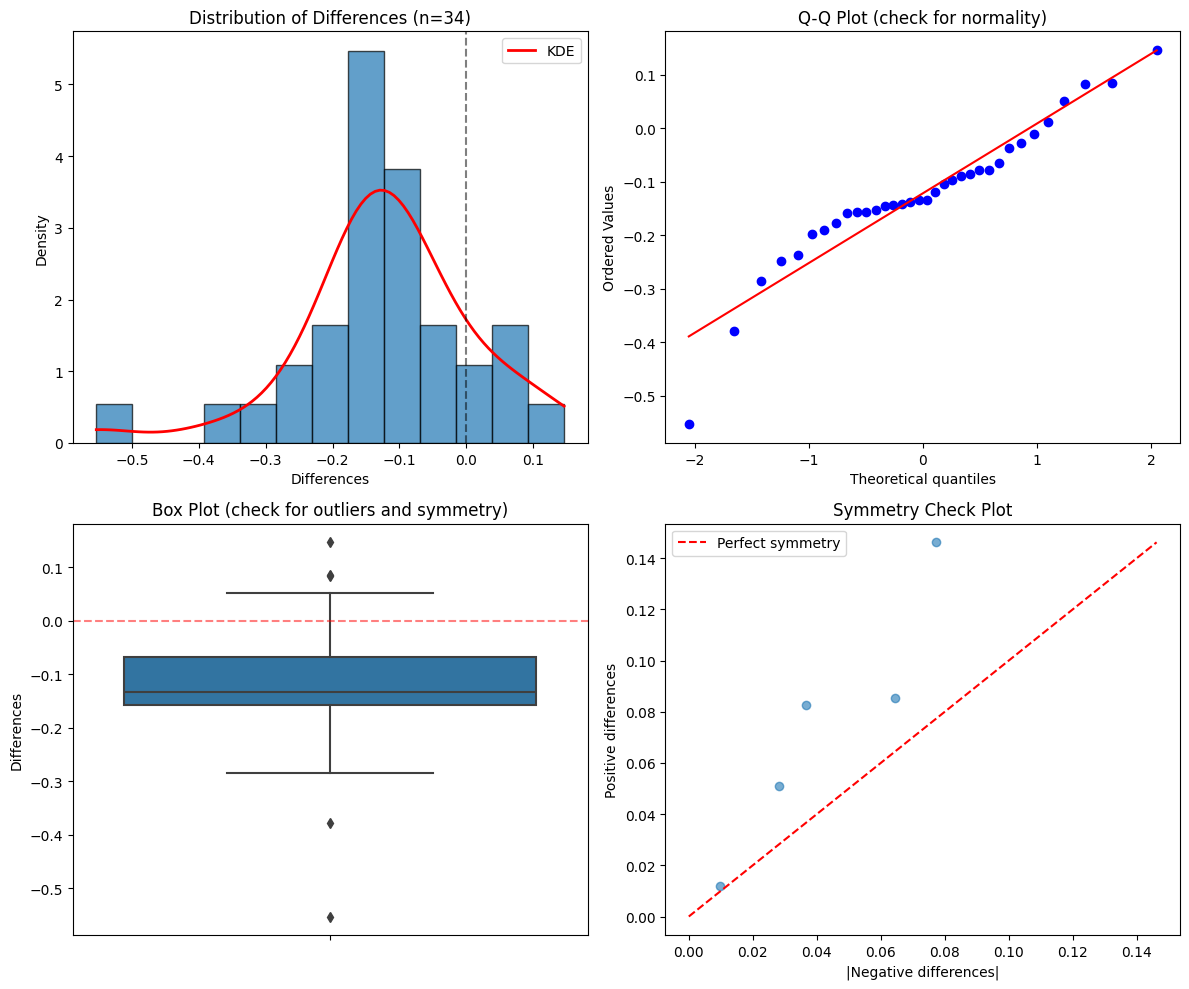

WILCOXON SIGNED-RANK TEST ASSUMPTIONS CHECK
Sample size: 34
Zero differences: 0
Tied ranks: 0 (0.0%)
Skewness: -0.796
Outliers: 5

WARNINGS:
  ⚠ Data shows moderate skewness (-0.80). Consider verifying results with sign test.
  ⚠ 5 outliers detected. These may affect the symmetry assumption.

RECOMMENDATIONS:
  • All major assumptions are satisfied. Wilcoxon signed-rank test is appropriate.

ASSUMPTIONS MET: YES ✓


In [6]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Union, Dict, Any

def check_wilcoxon_assumptions(diff_values: Union[np.ndarray, pd.Series, list], 
                               alpha: float = 0.05, 
                               plot: bool = True) -> Dict[str, Any]:
    """
    Check assumptions for Wilcoxon signed-rank test.
    
    Parameters:
    -----------
    diff_values : array-like
        The differences between paired observations (e.g., after - before)
    alpha : float, default=0.05
        Significance level for statistical tests
    plot : bool, default=True
        Whether to display diagnostic plots
    
    Returns:
    --------
    dict : Dictionary containing test results and recommendations
    """
    
    # Convert to numpy array
    diff = np.asarray(diff_values).flatten()
    
    # Remove NaN values
    diff = diff[~np.isnan(diff)]
    
    results = {
        'n_observations': len(diff),
        'assumptions_met': True,
        'warnings': [],
        'recommendations': []
    }
    
    # 1. Check sample size
    if len(diff) < 6:
        results['warnings'].append("Sample size is very small (n < 6). Results may be unreliable.")
        results['assumptions_met'] = False
    elif len(diff) < 20:
        results['warnings'].append("Small sample size. Consider exact p-values for Wilcoxon test.")
    
    # 2. Check for zeros (observations equal to hypothesized value)
    n_zeros = np.sum(diff == 0)
    results['n_zeros'] = n_zeros
    if n_zeros > 0:
        results['warnings'].append(f"{n_zeros} zero differences found. These will be excluded from the test.")
        diff_nonzero = diff[diff != 0]
    else:
        diff_nonzero = diff
    
    # 3. Check for ties
    unique_values = np.unique(np.abs(diff_nonzero))
    n_ties = len(diff_nonzero) - len(unique_values)
    results['n_ties'] = n_ties
    tie_proportion = n_ties / len(diff_nonzero) if len(diff_nonzero) > 0 else 0
    
    if tie_proportion > 0.1:
        results['warnings'].append(f"High proportion of ties ({tie_proportion:.1%}). Consider using exact p-values.")
    
    # 4. Check symmetry (most important assumption)
    if len(diff_nonzero) >= 8:  # Need sufficient data for symmetry tests
        
        # 4a. Skewness test
        skewness = stats.skew(diff_nonzero)
        results['skewness'] = skewness
        
        # Rule of thumb: |skewness| > 1 indicates substantial asymmetry
        if abs(skewness) > 1:
            results['warnings'].append(f"Data shows substantial skewness ({skewness:.2f}). Symmetry assumption may be violated.")
            results['assumptions_met'] = False
        elif abs(skewness) > 0.5:
            results['warnings'].append(f"Data shows moderate skewness ({skewness:.2f}). Consider verifying results with sign test.")
        
        # 4b. Statistical test for symmetry - compare positive and negative values
        pos_vals = diff_nonzero[diff_nonzero > 0]
        neg_vals = -diff_nonzero[diff_nonzero < 0]  # Make negative values positive
        
        if len(pos_vals) > 0 and len(neg_vals) > 0:
            # Kolmogorov-Smirnov test to compare distributions
            ks_stat, ks_pval = stats.ks_2samp(pos_vals, neg_vals)
            results['symmetry_test_pvalue'] = ks_pval
            
            if ks_pval < alpha:
                results['warnings'].append(f"Statistical test suggests asymmetry (p={ks_pval:.3f}). Consider using sign test instead.")
                results['assumptions_met'] = False
    
    # 5. Check for outliers
    Q1 = np.percentile(diff_nonzero, 25)
    Q3 = np.percentile(diff_nonzero, 75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = diff_nonzero[(diff_nonzero < lower_bound) | (diff_nonzero > upper_bound)]
    results['n_outliers'] = len(outliers)
    
    if len(outliers) > 0:
        results['warnings'].append(f"{len(outliers)} outliers detected. These may affect the symmetry assumption.")
    
    # 6. Generate recommendations
    if results['assumptions_met']:
        results['recommendations'].append("All major assumptions are satisfied. Wilcoxon signed-rank test is appropriate.")
    else:
        results['recommendations'].append("Consider using the sign test as it has fewer assumptions.")
        
    if len(diff) >= 30 and abs(skewness) < 0.5:
        results['recommendations'].append("With n≥30 and reasonable symmetry, paired t-test might also be considered.")
    
    # 7. Create diagnostic plots
    if plot and len(diff_nonzero) > 0:
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        # Histogram with kernel density
        ax1 = axes[0, 0]
        ax1.hist(diff_nonzero, bins='auto', density=True, alpha=0.7, edgecolor='black')
        
        # Add kernel density estimate
        if len(diff_nonzero) > 3:
            kde_x = np.linspace(diff_nonzero.min(), diff_nonzero.max(), 100)
            kde = stats.gaussian_kde(diff_nonzero)
            ax1.plot(kde_x, kde(kde_x), 'r-', linewidth=2, label='KDE')
        
        ax1.axvline(x=0, color='black', linestyle='--', alpha=0.5)
        ax1.set_xlabel('Differences')
        ax1.set_ylabel('Density')
        ax1.set_title(f'Distribution of Differences (n={len(diff_nonzero)})')
        ax1.legend()
        
        # Q-Q plot
        ax2 = axes[0, 1]
        stats.probplot(diff_nonzero, dist="norm", plot=ax2)
        ax2.set_title('Q-Q Plot (check for normality)')
        
        # Box plot
        ax3 = axes[1, 0]
        box_data = pd.DataFrame({'Differences': diff_nonzero})
        sns.boxplot(y='Differences', data=box_data, ax=ax3)
        ax3.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        ax3.set_title('Box Plot (check for outliers and symmetry)')
        
        # Symmetry plot: compare |positive| vs |negative| values
        ax4 = axes[1, 1]
        pos_abs = np.sort(diff_nonzero[diff_nonzero > 0])
        neg_abs = np.sort(np.abs(diff_nonzero[diff_nonzero < 0]))
        
        # Match lengths for comparison
        min_len = min(len(pos_abs), len(neg_abs))
        if min_len > 0:
            ax4.scatter(neg_abs[:min_len], pos_abs[:min_len], alpha=0.6)
            
            # Add diagonal line for perfect symmetry
            max_val = max(np.max(neg_abs[:min_len]), np.max(pos_abs[:min_len]))
            ax4.plot([0, max_val], [0, max_val], 'r--', label='Perfect symmetry')
            
            ax4.set_xlabel('|Negative differences|')
            ax4.set_ylabel('Positive differences')
            ax4.set_title('Symmetry Check Plot')
            ax4.legend()
        else:
            ax4.text(0.5, 0.5, 'Insufficient data for symmetry plot', 
                    ha='center', va='center', transform=ax4.transAxes)
        
        plt.tight_layout()
        plt.show()
    
    # Print summary
    print("="*60)
    print("WILCOXON SIGNED-RANK TEST ASSUMPTIONS CHECK")
    print("="*60)
    print(f"Sample size: {results['n_observations']}")
    print(f"Zero differences: {results['n_zeros']}")
    print(f"Tied ranks: {results['n_ties']} ({tie_proportion:.1%})")
    if 'skewness' in results:
        print(f"Skewness: {results['skewness']:.3f}")
    if 'n_outliers' in results:
        print(f"Outliers: {results['n_outliers']}")
    
    print("\nWARNINGS:")
    if results['warnings']:
        for warning in results['warnings']:
            print(f"  ⚠ {warning}")
    else:
        print("  ✓ No warnings")
    
    print("\nRECOMMENDATIONS:")
    for rec in results['recommendations']:
        print(f"  • {rec}")
    
    print("\nASSUMPTIONS MET:", "YES ✓" if results['assumptions_met'] else "NO ✗")
    print("="*60)
    
    return results


# Example usage with sample data
if __name__ == "__main__":

    print("Example 1: Symmetric differences")
    results1 = check_wilcoxon_assumptions(diff.values)

# create per study characteristics table

In [ ]:
# create per study characteristics table
grouped_by_study = metadata.groupby("Project_1")
df_study_characteristics = {}
for study, group in grouped_by_study:
    grouped_by_label = group.groupby("Group")
    df_study_characteristics[study] = {
        "n_samples": group.shape[0],
        "n_non_zero_features": (
            abundance_data.loc[group.index, :].sum(axis=0) > 0
        ).sum(),
        "n_pos": (group["Group"] == "Disease").sum(),
        "n_neg": (group["Group"] == "Control").sum(),
        "n_dis_group": disease_group_per_study.get(study, "unknown"),
    }

df_study_characteristics = pd.DataFrame(df_study_characteristics).T
df_study_characteristics["n_pos/n_neg"] = (
    df_study_characteristics["n_pos"] / df_study_characteristics["n_neg"]
)
df_study_characteristics = df_study_characteristics.sort_values(
    by="n_samples", ascending=False
)


In [24]:
display(df_study_characteristics)
display(df_study_characteristics.loc[studies_with_protonet_outperforming, :])

,n_samples,n_non_zero_features,n_pos,n_neg,n_dis_group,n_pos/n_neg
QinJ_2012,369,264,186,183,cardiometabolic disease,1.016393
ZengQ_2021,363,247,170,193,cardiometabolic disease,0.880829
JieZ_2017,363,278,203,160,cardiometabolic disease,1.26875
HanL_2021,361,220,277,84,digestive disease,3.297619
WangQ_2021,350,247,231,119,cardiometabolic disease,1.941176
WangX_2020,275,242,206,69,kidney disease,2.985507
ZhongH_2019,254,271,157,97,cardiometabolic disease,1.618557
YeohYK_2021,249,264,177,72,infectious disease,2.458333
QinN_2014,231,247,117,114,liver disease,1.026316
ChenB_2020,231,260,115,116,immune disease,0.991379


,n_samples,n_non_zero_features,n_pos,n_neg,n_dis_group,n_pos/n_neg
LiuR_2017,217,249,112,105,cardiometabolic disease,1.066667
ZuoK_2019,93,255,44,49,cardiometabolic disease,0.897959
LiR_2021,136,258,100,36,cardiometabolic disease,2.777778
HeQ_2017,98,238,46,52,digestive disease,0.884615
QinN_2014,231,247,117,114,liver disease,1.026316


# Jaccard similarity

In [3]:
import numpy as np
meta_inspired_f1s = {'YeZ_2018': np.float64(0.4666666666666667), 'HeQ_2017': np.float64(0.6923076923076923), 'ZengQ_2021': np.float64(0.5858585858585859), 'ChenB_2020': np.float64(0.7434944237918215), 'LiJ_2017': np.float64(0.765625), 'HanL_2021': np.float64(0.8051470588235294), 'ZhouC_2020': np.float64(0.765625), 'YeohYK_2021': np.float64(0.8075880758807588), 'YeZ_2020': np.float64(0.8166666666666667), 'WangX_2020': np.float64(0.8412698412698413), 'WangQ_2021': np.float64(0.6958424507658644), 'QiX_2019': np.float64(0.5853658536585366), 'MaoL_2021': np.float64(0.6835443037974683), 'QianY_2020': np.float64(0.651685393258427), 'ZhuQ_2021': np.float64(0.8044692737430168), 'LiuR_2017': np.float64(0.5842696629213483), 'QinJ_2012': np.float64(0.6818181818181818), 'QinN_2014': np.float64(0.7407407407407407), 'ZhuF_2020': np.float64(0.6492146596858639), 'JieZ_2017': np.float64(0.7651331719128329), 'WangM_2019': np.float64(0.7560975609756098), 'ZhongH_2019': np.float64(0.636986301369863), 'YangY_2021': np.float64(0.68), 'ZuoK_2019': np.float64(0.5494505494505495), 'YanQ_2017': np.float64(0.7358490566037735), 'HuY_2019': np.float64(0.7951807228915663), 'ChuY_2021': np.float64(0.7069767441860465), 'LiR_2021': np.float64(0.6451612903225806), 'ZhangX_2015': np.float64(0.6567164179104478), 'HuangR_2020': np.float64(0.8061224489795918), 'WanY_2021': np.float64(0.6708074534161491), 'YuJ_2017': np.float64(0.7692307692307693), 'ZhuJ_2018': np.float64(0.6716417910447762), 'LiuP_2021': np.float64(0.7346938775510204)}
meta_inspired_f1s_df = pd.DataFrame.from_dict(meta_inspired_f1s, orient="index", columns=["F1 Score"])
print(meta_inspired_f1s_df)


             F1 Score
YeZ_2018     0.466667
HeQ_2017     0.692308
ZengQ_2021   0.585859
ChenB_2020   0.743494
LiJ_2017     0.765625
HanL_2021    0.805147
ZhouC_2020   0.765625
YeohYK_2021  0.807588
YeZ_2020     0.816667
WangX_2020   0.841270
WangQ_2021   0.695842
QiX_2019     0.585366
MaoL_2021    0.683544
QianY_2020   0.651685
ZhuQ_2021    0.804469
LiuR_2017    0.584270
QinJ_2012    0.681818
QinN_2014    0.740741
ZhuF_2020    0.649215
JieZ_2017    0.765133
WangM_2019   0.756098
ZhongH_2019  0.636986
YangY_2021   0.680000
ZuoK_2019    0.549451
YanQ_2017    0.735849
HuY_2019     0.795181
ChuY_2021    0.706977
LiR_2021     0.645161
ZhangX_2015  0.656716
HuangR_2020  0.806122
WanY_2021    0.670807
YuJ_2017     0.769231
ZhuJ_2018    0.671642
LiuP_2021    0.734694


c:\Users\shaya\Documents\TU_projects\master_thesis\notebooks\..\visualizations\helper_functions.py:2737: UserWarning:

Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations



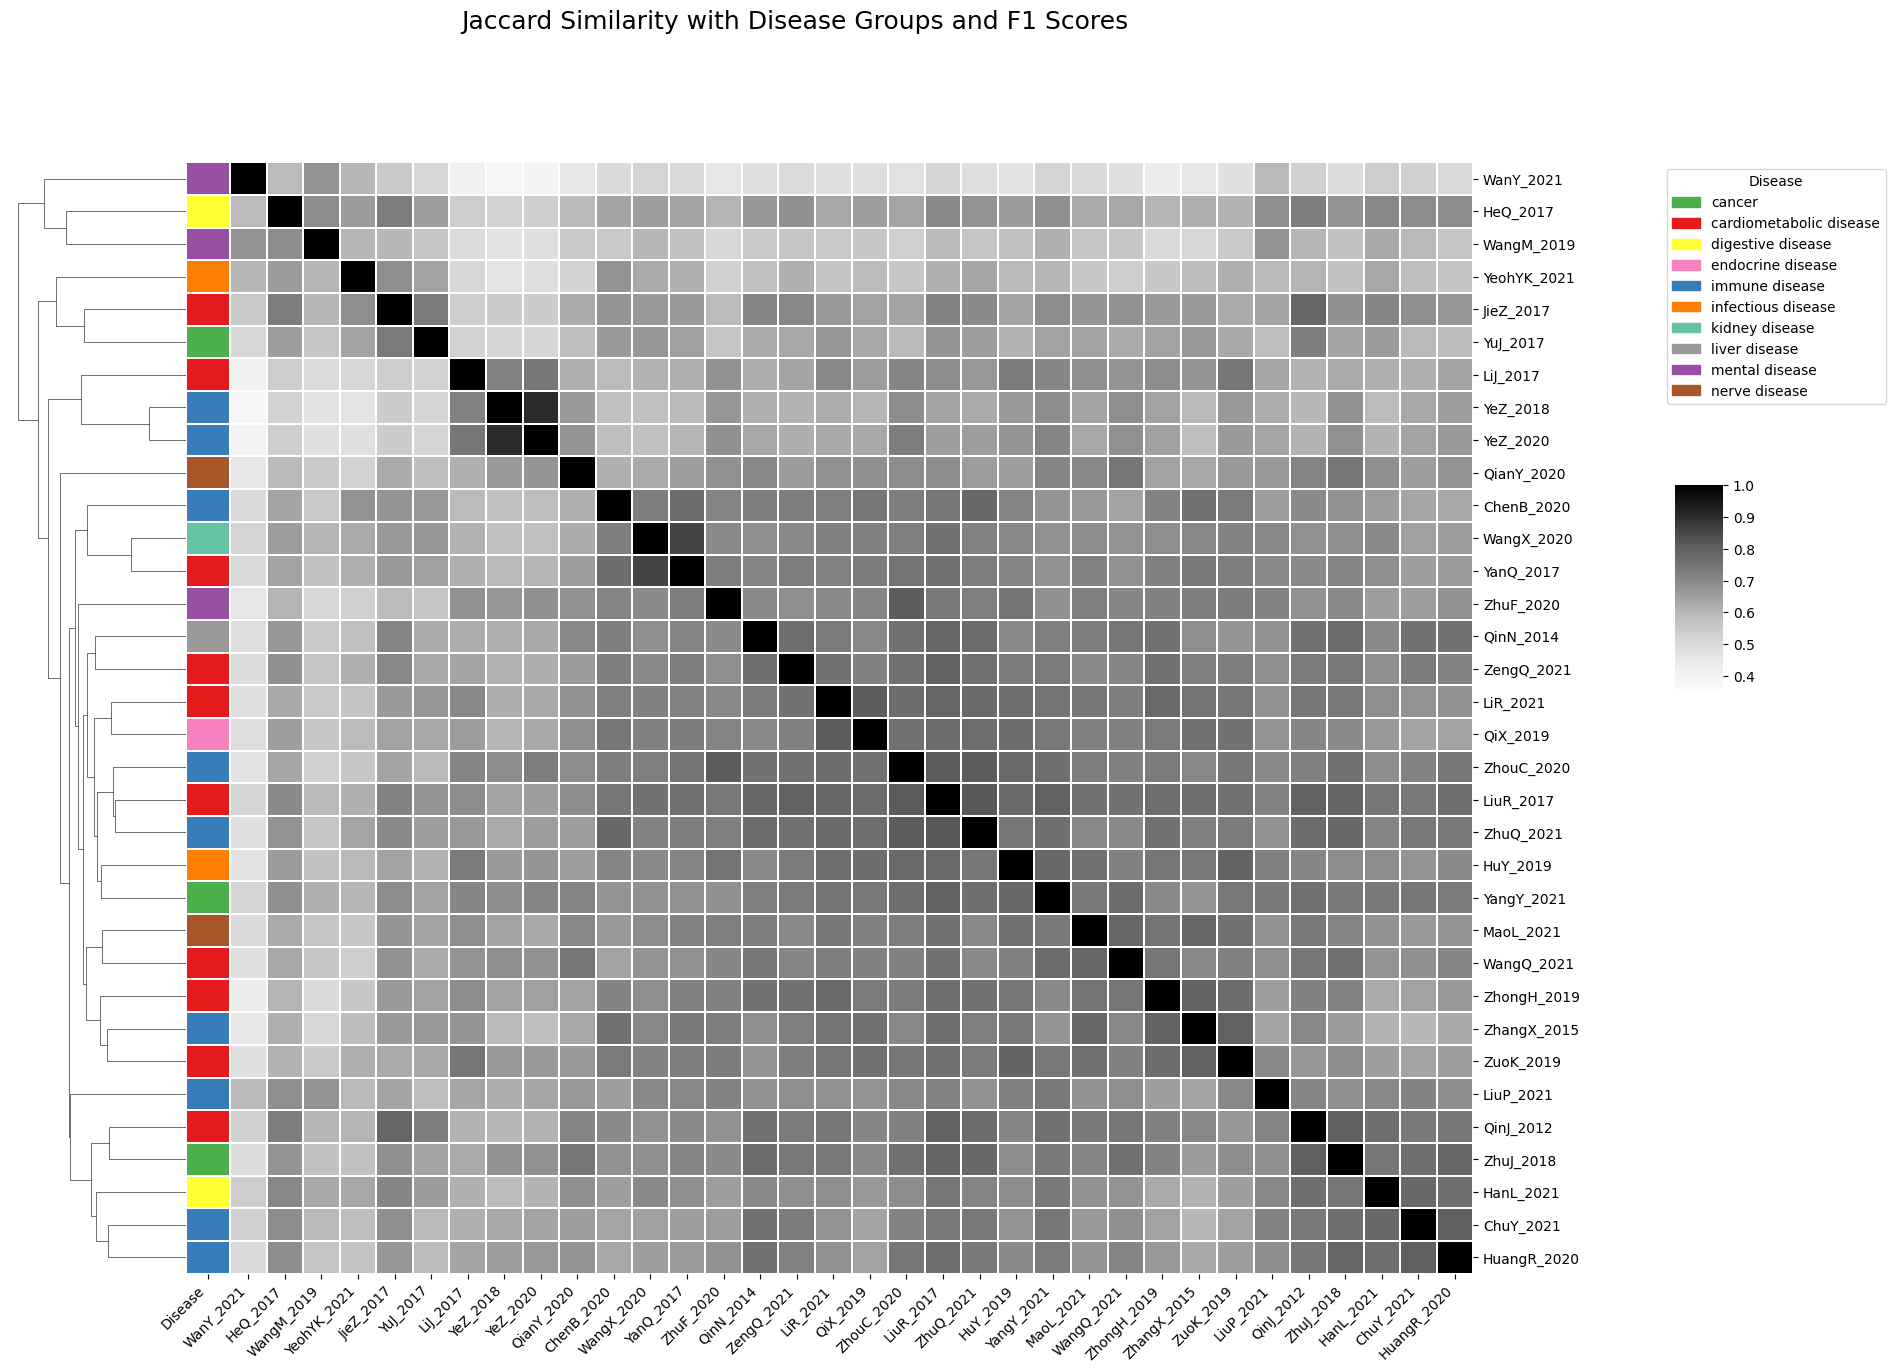

In [23]:
import sys

sys.path.append("../src")

import pandas as pd
import visualizations.helper_functions as hf

studies_to_drop = ["LuW_2018", "WengY_2019"]

# metadata = pd.read_csv("../data/sun_et_al_data/sample_group_species_preprocessed.csv", index_col=0, header=0)
# abundance_data = pd.read_csv('../data/sun_et_al_data/mpa4_species_profile_preprocessed.csv', index_col=0, header=0)

# # jaccard similarity of features of different studies
# grouped_by_study = metadata.groupby("Project_1")
# features_per_study = {}
# for study, group in grouped_by_study:
#     non_zero_features_of_study = abundance_data.columns[
#         abundance_data.loc[group.index, :].sum(axis=0) > 0
#     ].tolist()
#     features_per_study[study] = set(non_zero_features_of_study)

# jaccard_similarity = {}
# for i, study1 in enumerate(features_per_study.keys()):
#     if study1 in studies_to_drop:
#         continue
#     for study2 in list(features_per_study.keys())[i + 1 :]:
#         if study2 in studies_to_drop:
#             continue
#         intersection = features_per_study[study1].intersection(
#             features_per_study[study2]
#         )
#         union = features_per_study[study1].union(features_per_study[study2])
#         jaccard_similarity[(study1, study2)] = len(intersection) / len(union)

# jaccard_df = pd.DataFrame.from_dict(
#     jaccard_similarity, orient="index", columns=["Jaccard Similarity"]
# )
# jaccard_df.reset_index(inplace=True)
# jaccard_df[["Study1", "Study2"]] = pd.DataFrame(
#     jaccard_df["index"].tolist(), index=jaccard_df.index
# )
# jaccard_df.drop(columns=["index"], inplace=True)
# jaccard_df = jaccard_df.sort_values(by="Jaccard Similarity", ascending=False)



# # # jaccard similarity of each study again the union of all the other studies
# jaccard_similarity_against_union = {}
# for study, features in features_per_study.items():
#     if study in studies_to_drop:
#         continue
#     intersection = features
#     union = set().union(*[f for s, f in features_per_study.items() if s != study])
#     jaccard_similarity_against_union[study] = len(intersection) / len(union)
# jaccard_union_df = pd.DataFrame.from_dict(
#     jaccard_similarity_against_union, orient="index", columns=["Jaccard Similarity Against Union"]
# )
# jaccard_union_df.reset_index(inplace=True)
# jaccard_union_df.rename(columns={"index": "Study"}, inplace=True)
# jaccard_union_df = jaccard_union_df.sort_values(
#     by="Jaccard Similarity Against Union", ascending=False
# )



heatmap = hf.create_jaccard_clustermap_with_f1(jaccard_df, original_df, embedding_df, meta_inspired_f1s_df)
# heatmap.show()
# heatmap = hf.create_jaccard_heatmap_with_f1_table(
#     jaccard_df, original_df, embedding_df, meta_inspired_f1s_df, jaccard_union_df
# )
# heatmap.show()
heatmap.savefig(
    "./figures/jaccard_clustermap_with_diseases.png"
)

scatter_plot = hf.plot_f1_vs_jaccard_similarity(
    jaccard_df, original_df, embedding_df, meta_inspired_f1s_df
    )
scatter_plot.show()
scatter_plot.write_image(
    "./figures/f1_vs_jaccard_similarity.png"
)



# plot per study
# import seaborn as sns
# import matplotlib.pyplot as plt
# plt.figure(figsize=(15, 6))
# sns.barplot(
#     x="Study",
#     y="Jaccard Similarity Against Union",
#     data=jaccard_union_df,
#     color="gray",
#     # simple color palette
#     # palette="black",
# )
# plt.xticks(rotation=45)
# plt.title("Jaccard Similarity of Features Against Union of Other Studies")
# plt.xlabel("Study")
# plt.ylabel("Jaccard Similarity")
# plt.tight_layout()
# plt.show()




# # plot jaccard count bar chart, grouped by 0.05
# import matplotlib.pyplot as plt
# import seaborn as sns
# jaccard_counts = pd.Series(jaccard_similarity).value_counts().sort_index()
# plt.figure(figsize=(10, 6))
# jaccard_counts.index = pd.cut(jaccard_counts.index, bins=[0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1, 1.05], right=False)
# jaccard_counts = jaccard_counts.groupby(jaccard_counts.index).sum()
# sns.barplot(x=jaccard_counts.index.astype(str), y=jaccard_counts.values)
# plt.xlabel('Jaccard Similarity')
# plt.ylabel('Count')
# plt.title('Jaccard Similarity of Features between Studies')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# # print studies with jaccard similarity >= 0.8
# high_jaccard_studies = [studies for studies, jaccard in jaccard_similarity.items() if jaccard >= 0.8]
# print("Studies with Jaccard Similarity >= 0.8:")
# print(high_jaccard_studies)
# # their disease groups
# for study1, study2 in high_jaccard_studies:
#     print(f"{study1} ({disease_group_per_study.get(study1, 'unknown')}) - {study2} ({disease_group_per_study.get(study2, 'unknown')})")

## extra: Option 1: Feature correlation-based Mantel test

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from scipy.spatial.distance import squareform
from skbio.stats.distance import mantel
import seaborn as sns
import matplotlib.pyplot as plt


def calculate_study_correlation_matrices(abundance_data, metadata, studies_to_drop):
    """Calculate correlation matrices for each study."""
    grouped_by_study = metadata.groupby("Project_1")
    correlation_matrices = {}
    
    for study, group in grouped_by_study:
        if study in studies_to_drop:
            continue
        
        # Get abundance data for this study's samples
        study_abundance = abundance_data.loc[group.index, :]
        
        # Remove features with zero variance
        non_zero_var = study_abundance.var(axis=0) > 0
        study_abundance_filtered = study_abundance.loc[:, non_zero_var]
        
        # Calculate correlation matrix
        if study_abundance_filtered.shape[1] > 1:  # Need at least 2 features
            corr_matrix = study_abundance_filtered.corr(method='spearman')
            correlation_matrices[study] = corr_matrix
    
    return correlation_matrices

def perform_pairwise_mantel_tests(correlation_matrices):
    """Perform Mantel tests between all pairs of study correlation matrices."""
    studies = list(correlation_matrices.keys())
    mantel_results = {}
    
    for i, study1 in enumerate(studies):
        for study2 in studies[i+1:]:
            # Find common features
            common_features = list(set(correlation_matrices[study1].columns) & 
                                 set(correlation_matrices[study2].columns))
            
            if len(common_features) > 2:  # Need at least 3 features for meaningful test
                # Subset to common features
                matrix1 = correlation_matrices[study1].loc[common_features, common_features]
                matrix2 = correlation_matrices[study2].loc[common_features, common_features]
                
                # Convert to distance matrices (1 - correlation)
                dist1 = 1 - matrix1.values
                dist2 = 1 - matrix2.values
                
                # Ensure matrices are in condensed form for skbio
                dist1_condensed = squareform(dist1, checks=False)
                dist2_condensed = squareform(dist2, checks=False)
                
                # Perform Mantel test
                r, p_value, n = mantel(dist1_condensed, dist2_condensed, method='spearman')
                
                mantel_results[(study1, study2)] = {
                    'mantel_r': r,
                    'p_value': p_value,
                    'n_common_features': len(common_features)
                }
    
    return mantel_results

def create_mantel_heatmap(mantel_results):
    """Create a heatmap of Mantel test correlations."""
    # Convert results to DataFrame
    mantel_df = pd.DataFrame.from_dict(mantel_results, orient='index')
    mantel_df.reset_index(inplace=True)
    mantel_df[['Study1', 'Study2']] = pd.DataFrame(mantel_df['index'].tolist(), 
                                                    index=mantel_df.index)
    mantel_df.drop(columns=['index'], inplace=True)
    
    # Get unique studies
    studies = sorted(set(mantel_df['Study1'].unique()) | set(mantel_df['Study2'].unique()))
    n_studies = len(studies)
    
    # Create similarity matrix
    mantel_matrix = pd.DataFrame(np.zeros((n_studies, n_studies)), 
                                index=studies, columns=studies)
    
    for _, row in mantel_df.iterrows():
        study1, study2 = row['Study1'], row['Study2']
        mantel_r = row['mantel_r']
        mantel_matrix.loc[study1, study2] = mantel_r
        mantel_matrix.loc[study2, study1] = mantel_r
    
    np.fill_diagonal(mantel_matrix.values, 1.0)
    
    # Create heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(mantel_matrix, annot=True, fmt='.2f', cmap='RdBu_r', 
                center=0, vmin=-1, vmax=1, square=True,
                cbar_kws={'label': 'Mantel Correlation (r)'})
    plt.title('Mantel Test Correlations Between Study Feature Correlation Matrices', 
              fontsize=16, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    return mantel_matrix, plt.gcf()


correlation_matrices = calculate_study_correlation_matrices(abundance_data, metadata, studies_to_drop)
mantel_results = perform_pairwise_mantel_tests(correlation_matrices)
mantel_matrix, fig = create_mantel_heatmap(mantel_results)
# plt.savefig('./sun_et_al/mantel_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

KeyboardInterrupt: 

In [ ]:
# Option 2: Jaccard vs F1 similarity Mantel test
def calculate_f1_distance_matrix(f1_dfs, studies):
    """Calculate distance matrix based on F1 scores."""
    n_studies = len(studies)
    f1_distances = pd.DataFrame(np.zeros((n_studies, n_studies)), 
                               index=studies, columns=studies)
    
    for i, study1 in enumerate(studies):
        for j, study2 in enumerate(studies):
            if i != j:
                distances = []
                for df in f1_dfs:
                    if study1 in df.index and study2 in df.index:
                        # Calculate absolute difference in F1 scores
                        dist = abs(df.loc[study1, 'F1 Score'] - df.loc[study2, 'F1 Score'])
                        distances.append(dist)
                
                if distances:
                    # Average distance across all F1 score types
                    f1_distances.loc[study1, study2] = np.mean(distances)
    
    return f1_distances

def jaccard_to_distance(jaccard_df):
    """Convert Jaccard similarity to distance matrix."""
    studies = sorted(set(jaccard_df['Study1'].unique()) | set(jaccard_df['Study2'].unique()))
    n_studies = len(studies)
    
    jaccard_dist = pd.DataFrame(np.zeros((n_studies, n_studies)), 
                               index=studies, columns=studies)
    
    for _, row in jaccard_df.iterrows():
        study1, study2 = row['Study1'], row['Study2']
        # Convert similarity to distance
        distance = 1 - row['Jaccard Similarity']
        jaccard_dist.loc[study1, study2] = distance
        jaccard_dist.loc[study2, study1] = distance
    
    return jaccard_dist


studies = sorted(set(jaccard_df['Study1'].unique()) | set(jaccard_df['Study2'].unique()))
jaccard_dist = jaccard_to_distance(jaccard_df)
f1_dist = calculate_f1_distance_matrix([original_df, embedding_df, meta_inspired_f1s_df], studies)

# Ensure same order and convert to condensed form
common_studies = sorted(set(jaccard_dist.index) & set(f1_dist.index))
jaccard_condensed = squareform(jaccard_dist.loc[common_studies, common_studies].values)
f1_condensed = squareform(f1_dist.loc[common_studies, common_studies].values)

# Perform Mantel test
r, p_value, n = mantel(jaccard_condensed, f1_condensed, method='spearman')
print(f"Mantel test (Jaccard vs F1): r={r:.3f}, p={p_value:.3f}")

# misc

,Jaccard Similarity
"(HanL_2021, ZhangX_2015)",0.609375
"(HanL_2021, ChuY_2021)",0.778226
"(HanL_2021, ZhuF_2020)",0.651852
"(HanL_2021, WengY_2019)",0.481781
"(HanL_2021, ZengQ_2021)",0.685921
...,...
"(HuangR_2020, YeZ_2018)",0.652985
"(HuangR_2020, WangM_2019)",0.561151
"(MaoL_2021, YeZ_2018)",0.639175
"(MaoL_2021, WangM_2019)",0.565217


C:\Users\shaya\AppData\Local\Temp\ipykernel_3996\1771582305.py:62: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



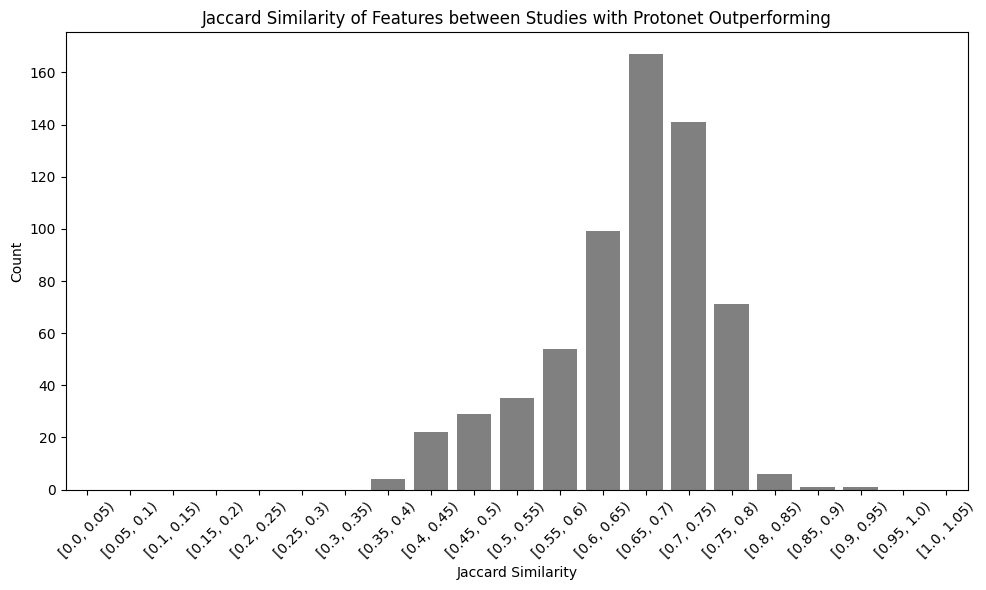

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns




# feature overlap of studies with protonet outperforming
studies = metadata["Project_1"].unique().tolist()
grouped_by_study = metadata.groupby("Project_1")
features_per_study = {}
for study in studies:
    group = grouped_by_study.get_group(study)
    features_per_study[study] = set(
        abundance_data.columns[abundance_data.loc[group.index, :].sum(axis=0) > 0]
    )

jaccard_similarity = {}
for i, study1 in enumerate(studies):
    for study2 in studies[i + 1 :]:
        intersection = features_per_study[study1].intersection(
            features_per_study[study2]
        )
        union = features_per_study[study1].union(features_per_study[study2])
        jaccard_similarity[(study1, study2)] = len(intersection) / len(union)
display(
    pd.DataFrame.from_dict(
        jaccard_similarity, orient="index", columns=["Jaccard Similarity"]
    )
)

# plot jaccard count bar chart, grouped by 0.05
jaccard_counts = pd.Series(jaccard_similarity).value_counts().sort_index()
plt.figure(figsize=(10, 6))
jaccard_counts.index = pd.cut(
    jaccard_counts.index,
    bins=[
        0,
        0.05,
        0.1,
        0.15,
        0.2,
        0.25,
        0.3,
        0.35,
        0.4,
        0.45,
        0.5,
        0.55,
        0.6,
        0.65,
        0.7,
        0.75,
        0.8,
        0.85,
        0.9,
        0.95,
        1,
        1.05,
    ],
    right=False,
)
jaccard_counts = jaccard_counts.groupby(jaccard_counts.index).sum()
sns.barplot(x=jaccard_counts.index.astype(str), y=jaccard_counts.values, color="gray")
plt.xlabel("Jaccard Similarity")
plt.ylabel("Count")
plt.title("Jaccard Similarity of Features between Studies with Protonet Outperforming")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("./figures/jaccard_sim.png", dpi=300, bbox_inches="tight")
plt.show()
# save


# # jaccard similarity of features of all studies in protonet outperforming
# intersection = set(features_per_study[studies_with_protonet_outperforming[0]])
# for study in studies_with_protonet_outperforming:
#     intersection = intersection.intersection(features_per_study[study])
# union = set()
# for study in studies_with_protonet_outperforming:
#     union = union.union(features_per_study[study])

# jaccard_similarity_all = len(intersection) / len(union) if union else 0
# print(
#     f"Jaccard Similarity of Features between Studies with Protonet Outperforming: {jaccard_similarity_all:.4f}"
# )

# # comapre union of features of all studies in protonet outperforming with union of features of all studies
# union_all_studies = set()
# for study in features_per_study:
#     union_all_studie╛s = union_all_studies.union(features_per_study[study])

# jaccard_similarity_union = (
#     len(union) / len(union_all_studies) if union_all_studies else 0
# )
# print(
#     f"Jaccard Similarity of Union of Features between Studies with Protonet Outperforming and All Studies: {jaccard_similarity_union:.4f}"
# )

In [6]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Data from your experiments
data = {
    "sqrt": {
        278: {
            80: 255,
            82: 272,
            84: 291,
            86: 318,
            88: 358,
            90: 423,
            92: 687,
            94: 1158,
            96: 1622,
            98: 2090,
            100: 2557,
            99: 2324,
        },
        59: {
            80: 207,
            82: 234,
            84: 270,
            86: 326,
            88: 434,
            90: 761,
            92: 1121,
            94: 1479,
            96: 1839,
            98: 2198,
            100: 2557,
            99: 2378,
        },
        500: {
            80: 304,
            82: 323,
            84: 346,
            86: 373,
            88: 405,
            90: 451,
            92: 641,
            94: 1120,
            96: 1599,
            98: 2078,
            100: 2557,
            99: 2318,
        },
        1000: {
            80: 304,
            82: 324,
            84: 347,
            86: 374,
            88: 406,
            90: 452,
            92: 642,
            94: 1121,
            96: 1600,
            98: 2079,
            100: 2557,
            99: 2318,
        },
    },
    "linear": {
        278: {
            80: 238,
            82: 264,
            84: 299,
            86: 355,
            88: 479,
            90: 815,
            92: 1164,
            94: 1512,
            96: 1861,
            98: 2209,
            100: 2557,
            99: 2383,
        }
    },
    "log": {
        278: {
            80: 236,
            82: 261,
            84: 293,
            86: 343,
            88: 439,
            90: 749,
            92: 1110,
            94: 1472,
            96: 1834,
            98: 2196,
            100: 2557,
            99: 2377,
        }
    },
    "none": {
        278: {
            80: 280,
            82: 292,
            84: 308,
            86: 327,
            88: 354,
            90: 391,
            92: 454,
            94: 830,
            96: 1412,
            98: 1987,
            100: 2557,
            99: 2270,
        }
    },
}

# Create the main interactive line plot
fig = go.Figure()
# "#1f77b4",  # blue
# "#ff7f0e",  # orange
# "#2ca02c",  # green
# "#d62728",  # red
# "#9467bd",  # purple
# "#8c564b",  # brown
# "#e377c2",  # pink
# "#7f7f7f",  # gray
# "#bcbd22",  # olive
# "#17becf",  # cyan
# Define colors and styles
colors = {"sqrt": "#ff7f0e", "linear": "#2ca02c", "log": "#d62728", "none": "#17becf"}
dash_styles = {59: "solid", 278: "dot", 500: "dash", 1000: "dashdot"}
symbols = {59: "circle", 278: "square", 500: "diamond", 1000: "cross"}

colors = {
    "sqrt-59": "#ff7f0e",
    "sqrt-278": "#2ca02c",
    "sqrt-500": "#d62728",
    "sqrt-1000": "#f9aa00",
    "linear-278": "#e40faf",
    "log-278": "#200cd4",
    "none-278": "#fbb800",
}


def add_jitter(values, jitter_amount=0.3):
    return [v + np.random.uniform(-jitter_amount, jitter_amount) for v in values]


# Add traces for each combination
for weighting, pc_data in data.items():
    for n_pc, threshold_data in pc_data.items():
        thresholds = sorted(threshold_data.keys())
        n_features = [threshold_data[t] for t in thresholds]

        jittered_thresholds = add_jitter(thresholds, jitter_amount=0.05)

        fig.add_trace(
            go.Scatter(
                x=thresholds,
                y=n_features,
                opacity=0.8,
                mode="lines",
                name=f"{weighting} (#PC={n_pc})",
                line=dict(
                    color=colors.get(weighting + "-" + str(n_pc), "black"),
                    dash=dash_styles.get(n_pc, "solid"),
                    width=3,
                ),
                # showlegend=False,
                # marker=dict(
                #     symbol=symbols.get(n_pc, 'circle'),
                #     size=10
                # ),
                # hovertemplate="skip"
                hovertemplate="<b>%{fullData.name}</b><br>"
                + "Variance Threshold: %{x}%<br>"
                + "Selected Features: %{y}<br>"
                + "<extra></extra>",
            )
        )

        # fig.add_trace(go.Scatter(
        #     x=jittered_thresholds,
        #     y=n_features,
        #     mode='markers',
        #     name=f'{weighting} (n_pc={n_pc})',
        #     marker=dict(
        #         symbol=symbols.get(n_pc, 'circle'),
        #         size=8,
        #         color=colors.get(weighting+"-"+str(n_pc), 'black'),
        #         line=dict(width=0)
        #     ),
        #     opacity=0.7,
        #     hovertemplate='<b>%{fullData.name}</b><br>' +
        #                  'Variance Threshold: %{customdata}%<br>' +
        #                  'Selected Features: %{y}<br>' +
        #                  '<extra></extra>',
        #     customdata=thresholds
        # ))

# Update layout
fig.update_layout(
    title={
        "text": "Feature Selection vs Variance Threshold<br>for Different PC Counts and Weighting Methods",
        "font": {"size": 20},
        "y": 0.95,  # Position title at the top
    },
    xaxis_title="Feature Importance Coverage (%)",
    yaxis_title="Number of Taxa Selected",
    hovermode="x unified",
    width=700,
    height=800,
    plot_bgcolor="rgba(250, 250, 250, 0.8)",
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01, font=dict(size=18), bgcolor="rgba(255,255,255,0.8)"),
    # margin=dict(b=20, t=100, l=20, r=20),
    xaxis=dict(showgrid=True, gridwidth=1, gridcolor="rgba(200, 200, 200, 0.5)", tickfont=dict(size=18),title=dict(font=dict(size=20), standoff=25)),
    yaxis=dict(showgrid=True, gridwidth=1, gridcolor="rgba(200, 200, 200, 0.5)", tickfont=dict(size=18), title=dict(font=dict(size=20), standoff=25)),
    # yaxis=dict(
    #     title=dict(text="UMAP 2", font=dict(size=32), standoff=5),
    #     tickfont=dict(size=30),
    # ),
)

fig.show()
fig.write_image(
    "./feature_selection_variance_thresholds.png", width=700, height=800, scale=1
)